# 1. Import and Install Dependencies

## 1.2 Load Dependencies

In [1]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
from split_audio_by_duration import split_audio_by_duration 

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

print(tf.test.gpu_device_name())
print(tf.config.get_visible_devices())

Num GPUs Available:  0
False

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 2. Build Data Loading Function

## 2.1 Define Paths to Files

In [4]:
# POSITIVE_FILE = os.path.join('audios', 'positive', '0.wav')
# NEGATIVE_FILE = os.path.join('audios', 'negative', '0.wav')
# POSITIVE_FILE = os.path.join('audio_segments', 'positive', 'rec55_250_10_chunk_1.wav')
# NEGATIVE_FILE = os.path.join('audio_segments', 'negative', 'rec1_250_10_chunk_1.wav')
# POSITIVE_FILE = os.path.join('audio_segments_test_centrum', 'positive', 'rec55_250_10_chunk_1.wav')
# NEGATIVE_FILE = os.path.join('audio_segments_test_centrum', 'negative', 'rec1_250_10_chunk_1.wav')
POSITIVE_FILE = os.path.join('audio_segments_test_centrum_reduced', 'positive', 'rec55_250_10_chunk_1.wav')
NEGATIVE_FILE = os.path.join('audio_segments_test_centrum_reduced', 'negative', 'rec1_250_10_chunk_1.wav')

In [5]:
file_contents = tf.io.read_file(POSITIVE_FILE)
file_contents

<tf.Tensor: shape=(), dtype=string, numpy=b'RIFFd\x1f\x00\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00data@\x1f\x00\x00\xf0\xff\xf0\xff\xac\xff\xac\xff\xd6\xff\xd6\xff\xc2\xff\xc2\xff\x84\x01\x84\x01\x0e\xff\x0e\xff \x00 \x00@\xff@\xff\x90\xff\x90\xffx\xffx\xffJ\x00J\x00\xe0\xff\xe0\xff\x06\x01\x06\x01\xa4\xfe\xa4\xfe\xa6\x00\xa6\x00(\xff(\xff\xb6\xff\xb6\xfft\x00t\x00\xc2\xfe\xc2\xfe|\x01|\x01$\x00$\x00\xec\xfe\xec\xfed\xffd\xff\xcc\x00\xcc\x00\xe2\xff\xe2\xff\x00\x00\x00\x00\xba\xff\xba\xff\x06\x00\x06\x00\x8c\x00\x8c\x00>\x00>\x00:\xff:\xff\x9a\x00\x9a\x00\xd4\xff\xd4\xff\xa6\x00\xa6\x00h\x00h\x00\xc4\xfe\xc4\xfe\xec\x00\xec\x00\xdc\xff\xdc\xfft\xfft\xff\x9e\xff\x9e\xff\x98\x00\x98\x00:\x00:\x00l\xffl\xffn\x00n\x00\xe4\xff\xe4\xff \x00 \x006\xff6\xff\xd6\xff\xd6\xff:\x01:\x01\xfe\xfd\xfe\xfdb\x00b\x00\xac\xff\xac\xff\xd2\xff\xd2\xffn\x00n\x00\xea\xfe\xea\xfeB\xffB\xff\xfc\x00\xfc\x00\xd0\xff\xd0\xff2\xff2\xff<\x00<\x00\x1e\x00\x1e\x00\xdc\xff

In [6]:
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
sample_rate

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

## 2.2 Build Dataloading Function

In [7]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

## 2.3 Plot Wave

In [8]:
wave = load_wav_16k_mono(POSITIVE_FILE)
nwave = load_wav_16k_mono(NEGATIVE_FILE)

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: audio_segments_test_centrum_reduced\negative\rec1_250_10_chunk_1.wav : Das System kann die angegebene Datei nicht finden.
; No such file or directory [Op:ReadFile]

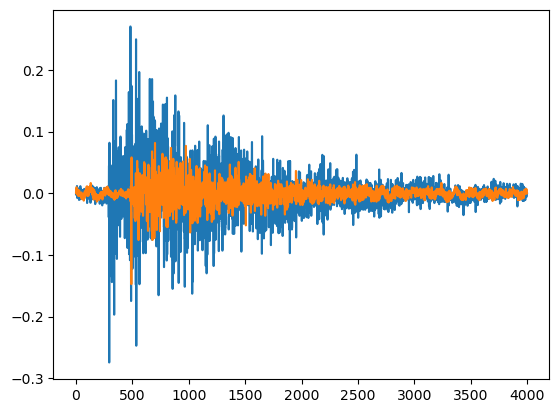

In [ ]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

# 3. Create Tensorflow Dataset

## 3.1 Define Paths to Positive and Negative Data

In [10]:
# POS = os.path.join('./', 'audios', 'positive')
# NEG = os.path.join('./', 'audios', 'negative')
# POS = os.path.join('./', 'audio_segments', 'positive')
# NEG = os.path.join('./', 'audio_segments', 'negative')
# POS = os.path.join('./', 'audio_segments_test_centrum', 'positive')
# NEG = os.path.join('./', 'audio_segments_test_centrum', 'negative')
POS = os.path.join('./', 'audio_segments_test_centrum_reduced', 'positive')
NEG = os.path.join('./', 'audio_segments_test_centrum_reduced', 'negative')

## 3.2 Create Tensorflow Datasets

In [11]:
pos = tf.data.Dataset.list_files(POS+'\*.wav')
neg = tf.data.Dataset.list_files(NEG+'\*.wav')

## 3.3 Add labels and Combine Positive and Negative Samples

In [12]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

# 4. Determine Average Length of a file

## 4.1 Calculate Wave Cycle Length

In [13]:
lengths = []
for file in os.listdir(os.path.join('./', 'audios', 'positive')):
    tensor_wave = load_wav_16k_mono(os.path.join('./', 'audios', 'positive', file))
    lengths.append(len(tensor_wave))

## 4.2 Calculate Mean, Min and Max

In [14]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [15]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [16]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

# 5. Build Preprocessing Function to Convert to Spectrogram

## 5.1 Build Preprocessing Function

In [17]:
def preprocess(file_path, label):
    wav = load_wav_16k_mono(file_path)
    wav = wav[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

## 5.2 Test Out the Function and Viz the Spectrogram

In [18]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [19]:
spectrogram, label = preprocess(filepath, label)
print(spectrogram.shape)

(491, 257, 1)


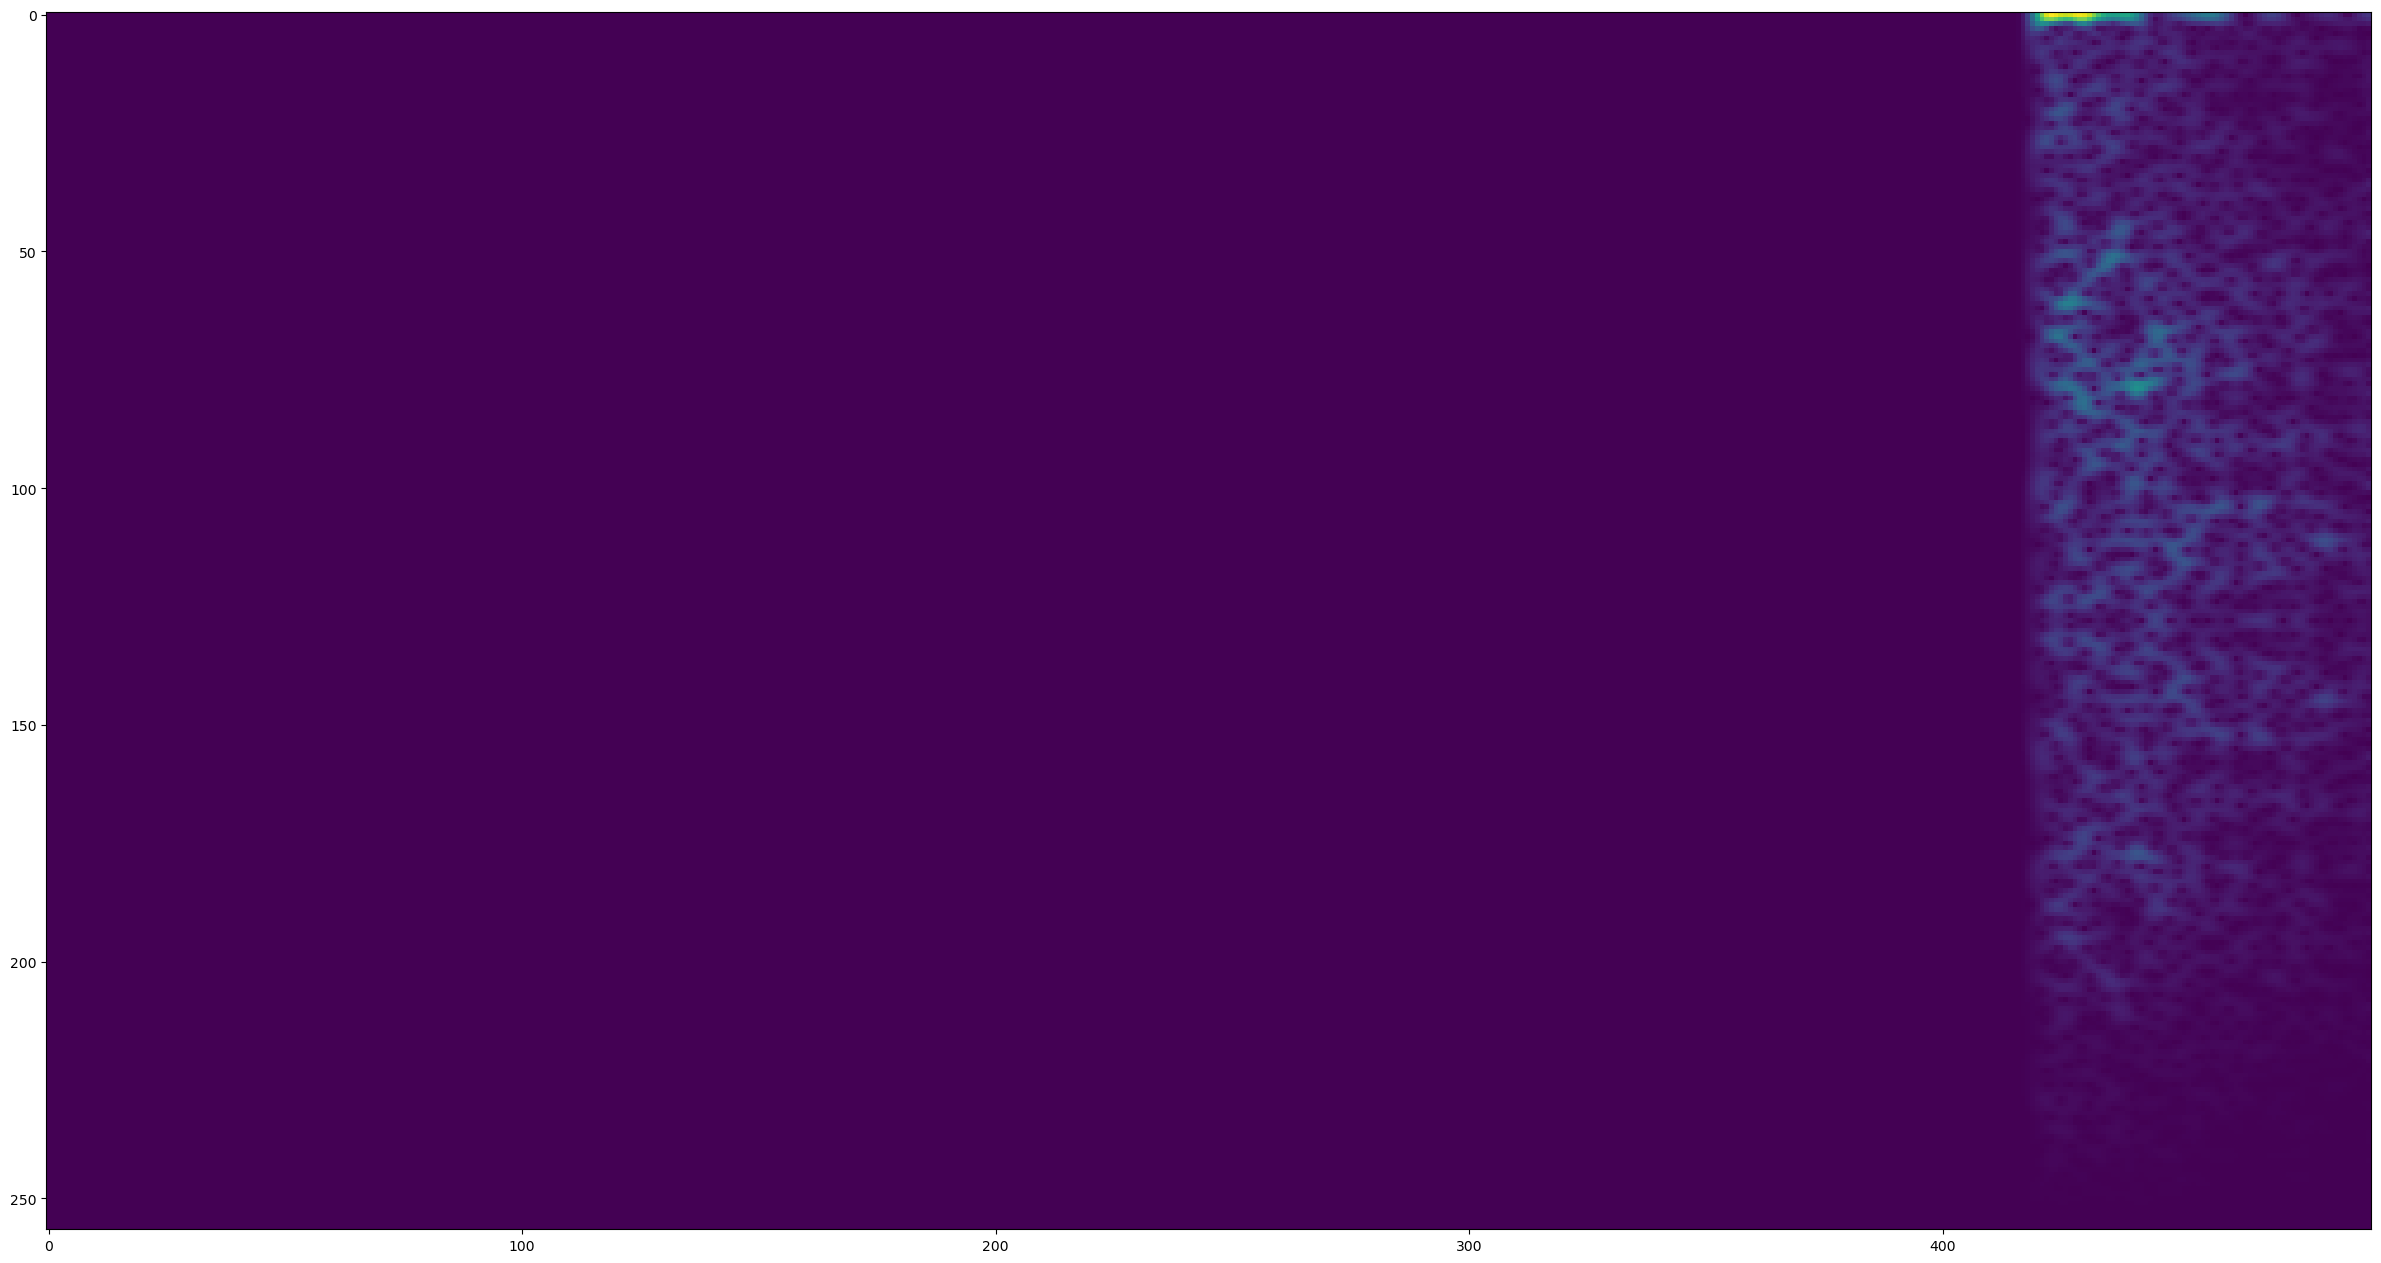

In [20]:
plt.figure(figsize=(30,20))
mel_spectrogram = tfio.audio.melscale(
    spectrogram, rate=16000, mels=128, fmin=0, fmax=8000)
dbscale_mel_spectrogram = tfio.audio.dbscale(
    mel_spectrogram, top_db=80)
# plt.imshow(tf.math.log(mel_spectrogram).numpy()[0])
# plt.imshow(dbscale_mel_spectrogram.numpy()[0])
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# 6. Create Training and Testing Partitions

## 6.1 Create a Tensorflow Data Pipeline

In [21]:
print(len(data))
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

5102


## 6.2 Split into Training and Testing Partitions

In [22]:
len(data)*.8

255.20000000000002

In [23]:
train = data.take(int(len(data)*.8))
test = data.skip(int(len(data)*.8)).take(int(len(data)-len(data)*.8))

## 6.3 Test One Batch

In [24]:
samples, labels = train.as_numpy_iterator().next()

In [25]:
labels

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
      dtype=float32)

In [26]:
samples.shape

(16, 491, 257, 1)

# 7. Build Deep Learning Model

## 7.1 Load Tensorflow Dependencies

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras import regularizers

## 7.2 Build Sequential Model, Compile and View Summary

In [28]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [29]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision(), tf.keras.metrics.Accuracy()])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 489, 255, 16)      160       
                                                                 
 conv2d_1 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 flatten (Flatten)           (None, 1971376)           0         
                                                                 
 dense (Dense)               (None, 128)               252336256 
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 252,338,865
Trainable params: 252,338,865
Non-trainable params: 0
_________________________________________________________________


## 7.3 Fit Model, View Loss and KPI Plots

In [51]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
700/700 [==============================] - 1388s 2s/step - loss: 0.3060 - recall_1: 0.9809 - precision_1: 0.9503 - accuracy: 0.4762 - val_loss: 0.4424 - val_recall_1: 0.3333 - val_precision_1: 1.0000 - val_accuracy: 0.0000e+00
Epoch 2/4
700/700 [==============================] - 1415s 2s/step - loss: 0.2276 - recall_1: 0.9671 - precision_1: 0.9811 - accuracy: 0.4711 - val_loss: 0.3182 - val_recall_1: 1.0000 - val_precision_1: 1.0000 - val_accuracy: 0.0000e+00
Epoch 3/4
700/700 [==============================] - 1330s 2s/step - loss: 0.0713 - recall_1: 0.9719 - precision_1: 0.9855 - accuracy: 0.4633 - val_loss: 3.3607e-04 - val_recall_1: 0.0000e+00 - val_precision_1: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 4/4
700/700 [==============================] - 1389s 2s/step - loss: 0.0734 - recall_1: 0.9779 - precision_1: 0.9872 - accuracy: 0.4817 - val_loss: 0.0034 - val_recall_1: 0.3333 - val_precision_1: 1.0000 - val_accuracy: 0.0000e+00


In [ ]:
# Save the model
tf.keras.models.save_model('audio_classification_model.h5')

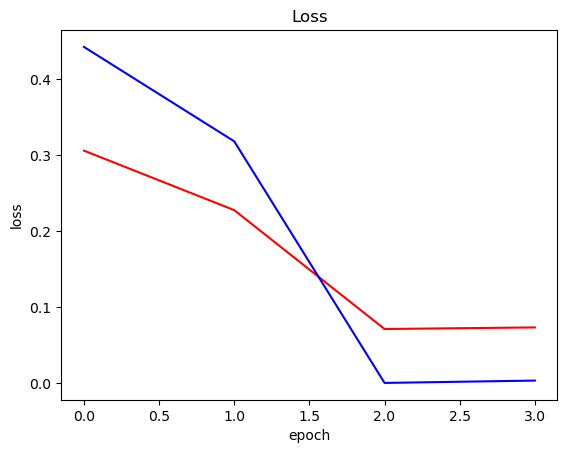

In [52]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

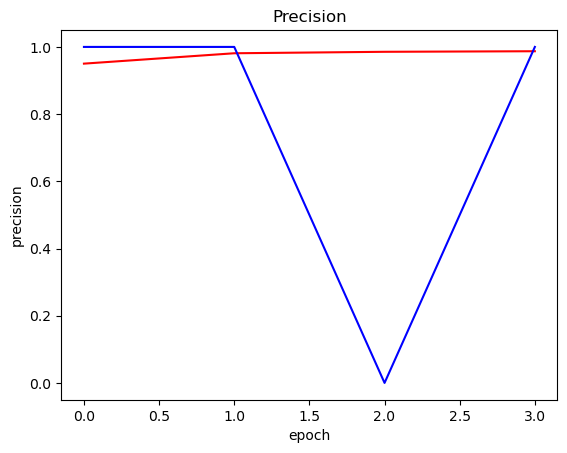

In [54]:
plt.title('Precision')
plt.plot(hist.history['precision_1'], 'r')
plt.plot(hist.history['val_precision_1'], 'b')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.show()

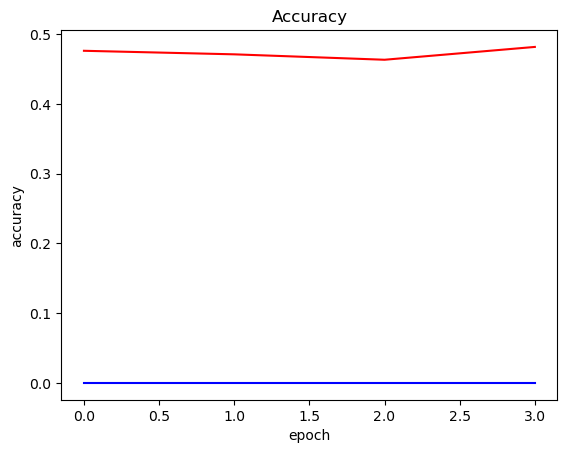

In [56]:
plt.title('Accuracy')
plt.plot(hist.history['accuracy'], 'r')
plt.plot(hist.history['val_accuracy'], 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

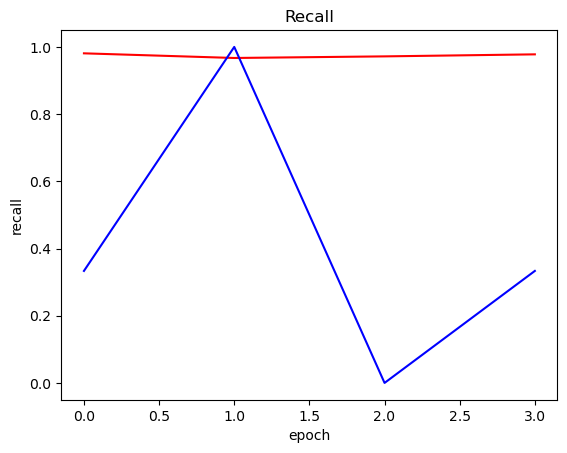

In [57]:
plt.title('Recall')
plt.plot(hist.history['recall_1'], 'r')
plt.plot(hist.history['val_recall_1'], 'b')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.show()

In [31]:
# Model version with l2 regularization and dropout

model2 = Sequential()
model2.add(Conv2D(16, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(491, 257,1)))
model2.add(Conv2D(16, (3,3), kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model2.add(BatchNormalization())
model2.add(Flatten())
model2.add(Dense(128, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model2.add(Dropout(0.35))
model2.add(Dense(1, kernel_regularizer=regularizers.l2(0.001), activation='sigmoid'))

model2.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision(), tf.keras.metrics.Accuracy()])

model2.summary()

# model2 = Sequential()
# model2.add(Conv2D(16, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(491, 257,1)))
# model2.add(Conv2D(16, (3,3), kernel_regularizer=regularizers.l2(0.01), activation='relu'))
# model2.add(BatchNormalization())
# model2.add(Flatten())
# model2.add(Dense(128, kernel_regularizer=regularizers.l2(0.01), activation='relu'))
# model2.add(Dropout(0.5))
# model2.add(Dense(1, kernel_regularizer=regularizers.l2(0.01), activation='sigmoid'))

# model2.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision(), tf.keras.metrics.Accuracy()])

# model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 489, 255, 16)      160       
                                                                 
 conv2d_3 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 batch_normalization (BatchN  (None, 487, 253, 16)     64        
 ormalization)                                                   
                                                                 
 flatten_1 (Flatten)         (None, 1971376)           0         
                                                                 
 dense_2 (Dense)             (None, 128)               252336256 
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                      

In [32]:
# hist2 = model2.fit(train, epochs=8, validation_data=test, batch_size=23)
hist2 = model2.fit(train, epochs=4, validation_data=test)

Epoch 1/4
255/255 [==============================] - 540s 2s/step - loss: 8.9759 - recall_1: 0.9870 - precision_1: 0.9874 - accuracy: 0.9784 - val_loss: 4.6313 - val_recall_1: 1.0000 - val_precision_1: 1.0000 - val_accuracy: 1.0000
Epoch 2/4
255/255 [==============================] - 515s 2s/step - loss: 2.0886 - recall_1: 0.9996 - precision_1: 0.9996 - accuracy: 0.9973 - val_loss: 1.0085 - val_recall_1: 1.0000 - val_precision_1: 1.0000 - val_accuracy: 1.0000
Epoch 3/4
255/255 [==============================] - 551s 2s/step - loss: 6.3134 - recall_1: 0.9967 - precision_1: 0.9911 - accuracy: 0.9922 - val_loss: 3.6634 - val_recall_1: 1.0000 - val_precision_1: 1.0000 - val_accuracy: 1.0000
Epoch 4/4
255/255 [==============================] - 642s 3s/step - loss: 1.7829 - recall_1: 1.0000 - precision_1: 1.0000 - accuracy: 0.9985 - val_loss: 0.9345 - val_recall_1: 1.0000 - val_precision_1: 1.0000 - val_accuracy: 1.0000


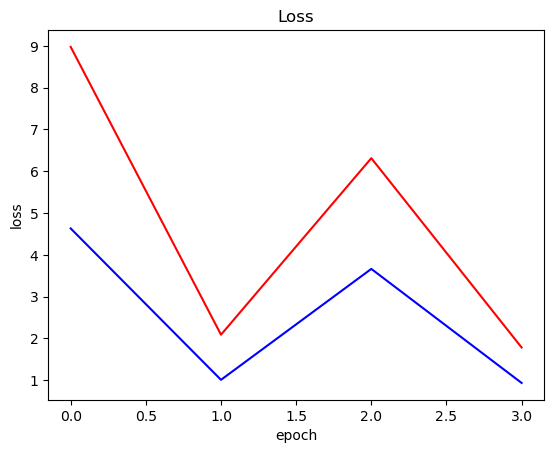

In [33]:
plt.title('Loss')
plt.plot(hist2.history['loss'], 'r')
plt.plot(hist2.history['val_loss'], 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

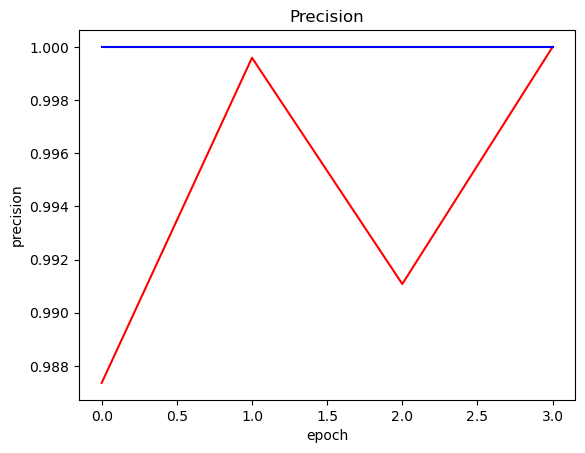

In [34]:
plt.title('Precision')
plt.plot(hist2.history['precision_1'], 'r')
plt.plot(hist2.history['val_precision_1'], 'b')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.show()

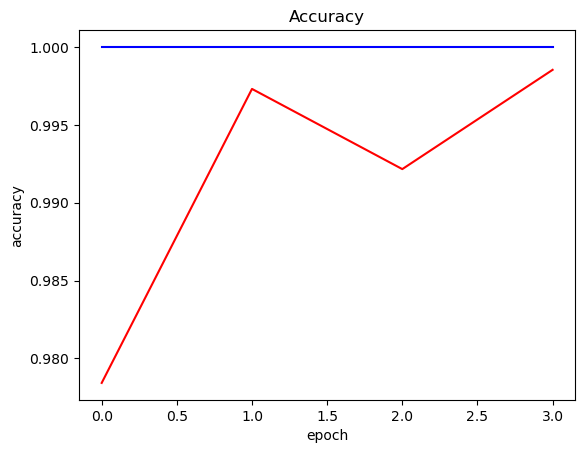

In [35]:
plt.title('Accuracy')
plt.plot(hist2.history['accuracy'], 'r')
plt.plot(hist2.history['val_accuracy'], 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

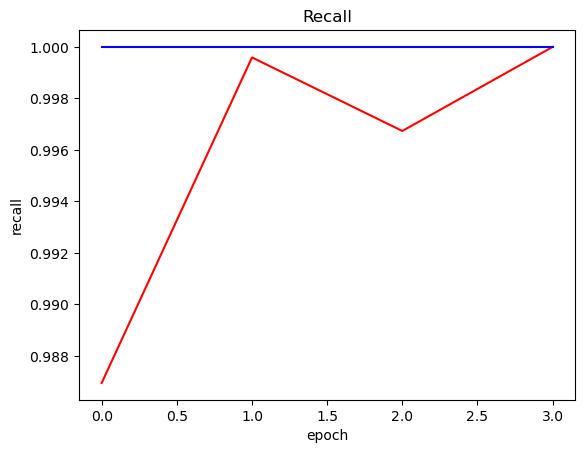

In [37]:
plt.title('Recall')
plt.plot(hist2.history['recall_1'], 'r')
plt.plot(hist2.history['val_recall_1'], 'b')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.show()

In [71]:
import datetime
# Current date and time 
current_datetime = datetime.datetime.now(datetime.timezone.utc)
formatted_datetime = current_datetime.strftime("%Y_%m_%d_%H%M%S")

# Create file name with date and time
model_filename = f"valve_classification_{formatted_datetime}.keras"

# Save the entire model as a `.keras` zip archive
model2.save(model_filename)

In [91]:
saved_model = tf.keras.models.load_model("valve_classification_2023_10_11_180812.keras")

# Show the model architecture
saved_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 489, 255, 16)      160       
                                                                 
 conv2d_3 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 batch_normalization (BatchN  (None, 487, 253, 16)     64        
 ormalization)                                                   
                                                                 
 flatten_1 (Flatten)         (None, 1971376)           0         
                                                                 
 dense_2 (Dense)             (None, 128)               252336256 
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                      

# 8. Make a Prediction on a Single Clip

## 8.1 Get One Batch and Make a Prediction

In [38]:
X_test, y_test = test.as_numpy_iterator().next()
print(X_test.shape)
print(y_test.shape)

(16, 491, 257, 1)
(16,)


In [73]:
# yhat = model.predict(X_test)
# yhat[:3]
yhat = model2.predict(X_test)
yhat[:3]

1/1 [==============================] - 4s 4s/step


array([[0.],
       [1.],
       [0.]], dtype=float32)

## 8.2 Convert Logits to Classes 

In [41]:
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]
yhat

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

In [44]:
print(tf.math.reduce_sum(yhat))
print(tf.math.reduce_sum(y_test))

tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(2.0, shape=(), dtype=float32)


In [45]:
print(yhat)
print(y_test.astype(int))

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


# 9. Build Forest Parsing Functions

## 9.1 Load up MP3s

In [46]:
#wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
wav_path = os.path.join('./', 'audios', 'test', 'rec5.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec8.wav')

print(wav_path)
wav_path = os.path.join('../','./', 'audios', 'rec', 'rec5.wav')
print(wav_path)

./audios\test\rec5.wav
.././audios\rec\rec5.wav


In [47]:
wav = load_wav_16k_mono(wav_path)
wav.shape

TensorShape([716800])

In [67]:
# print(wav)

import soundfile as sf
import numpy as np
import librosa
import scipy.signal as sps
signal, samplerate = sf.read(wav_path)
signal = np.float32(signal)
samplerate = np.int64(samplerate)
signal = librosa.resample(signal, orig_sr=samplerate, target_sr=160000)
# signal = sps.resample(signal, round(len(signal) * float(16000) / samplerate))
print(signal)



# import librosa
# y, sr = librosa.load(wav_path)
# print(y)

file_contents = tf.io.read_file(wav_path)
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
wav = tf.squeeze(wav, axis=-1)
sample_rate = tf.cast(sample_rate, dtype=tf.int64)
wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
print(wav)


[-0.00110311 -0.00129091 -0.00138292 ...  0.0017152   0.00106631
  0.0005052 ]
tf.Tensor(
[-6.7095005e-09  2.0027615e-08 -5.2226195e-08 ...  2.3132316e-03
  2.4486021e-03  2.4340709e-03], shape=(716800,), dtype=float32)


In [48]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [49]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)

In [50]:
samples, index = audio_slices.as_numpy_iterator().next()

In [51]:
len(audio_slices)

44

In [52]:
samples.shape

(1, 16000)

In [48]:
print(tf.slice(wav,
               begin=[15997],
               size=[1]))
print(samples[0])
print(wav)

import numpy as np
t1 = wav.numpy()

print(np.array_equal(t1[:16000], samples[0]))

print(t1[:16000])
print(samples[0])

print(index)

tf.Tensor([-0.00073242], shape=(1,), dtype=float32)
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
tf.Tensor(
[-0.00115967 -0.00115967 -0.00164795 ...  0.00463867  0.00695801
  0.00695801], shape=(716800,), dtype=float32)
True
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
[-0.00115967]


## 9.2 Build Function to Convert Clips into Windowed Spectrograms

In [53]:
def preprocess_2(sample, index):
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

## 9.3 Convert Longer Clips into Windows and Make Predictions

In [54]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
audio_slices = audio_slices.map(preprocess_2)
audio_slices = audio_slices.batch(64)

In [55]:
len(audio_slices)

1

In [56]:
# yhat = model.predict(audio_slices)
# SCHWELLENWERT = 0.52
# yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
# print(yhat)
yhat = model2.predict(audio_slices)
SCHWELLENWERT = 0.52
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
print(yhat)

1/1 [==============================] - 1s 1s/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]


## Test for audio cutting

In [57]:
# Audio cutting/preparation
from pydub import AudioSegment
import os
import shutil
import numpy as np
import math

# Removes silence at the beginning of wav file
def remove_silence_start(wav_path, output_file, silence_threshold=-46):
    audio = AudioSegment.from_wav(wav_path)
    print("Cutting silence at the beginning of the audio file...")

    # Find index of first not silent sample
    start_index = next((i for i, x in enumerate(audio) if x.dBFS > silence_threshold), None)

    # start_index += 5350

    # Safety buffer for not cutting to much of the last valve sound
    safety_buffer = 30

    if (start_index is not None) and (start_index > safety_buffer):
        # Cut silence at the beginning of the audio
        print(f"Old audio length: {len(audio)} ms")
        audio = audio[start_index - safety_buffer:]
        print(f"New audio length: {len(audio)} ms\n")
    else:
        print("No cutting required\n")

    # Save edited file
    audio.export(output_file, format="wav")

# Removes silence at the end of wav file
def remove_silence_end(wav_path, output_file, silence_threshold=-46):
    audio = AudioSegment.from_wav(wav_path)
    print("Cutting silence at the end of the audio file...")

    # Find index of last not silent sample
    end_index = next((len(audio) - 1 - i for i, x in enumerate(reversed(audio)) if x.dBFS > silence_threshold), None)

    # Safety buffer for not cutting to much of the last valve sound
    safety_buffer = 30

    if (end_index is not None) and ((end_index + safety_buffer) < (len(audio) - 1)):
        # Cut silence at the end of the audio
        print(f"Old audio length: {len(audio)} ms")
        audio = audio[:-(len(audio) - (end_index + safety_buffer) - 1)]
        print(f"New audio length: {len(audio)} ms\n")
    else:
        print("No cutting required\n")

    # Save edited file
    audio.export(output_file, format="wav")

# Determine the k-th percentile based on the proportion of valve noise in the audio file
def get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=0.9):
    audio = AudioSegment.from_wav(wav_path)

    # Takes a sample out of the middle of the audio file for the percentile determination -> beginning/end of audio file could contain silence
    # samples = []
    # for i, x in enumerate(audio[len(audio)/2 - 4*(cycle_duration):len(audio)/2]):
    #     samples.append(x.dBFS)

    samples = []
    for i, x in enumerate(audio[len(audio)*0.25 - 4*(cycle_duration):len(audio)*0.25]):
        samples.append(x.dBFS)

    for i, x in enumerate(audio[len(audio)*0.75 - 4*(cycle_duration):len(audio)*0.75]):
        samples.append(x.dBFS)

    # Determines percentile
    noise_percentage = 100 - (100 * (valve_time / cycle_duration))
    percentile_dbfs = np.percentile(samples, noise_percentage)
    percentile_dbfs = math.trunc(percentile_dbfs)
    print(f"{noise_percentage}% of the audio file is quieter than {percentile_dbfs} dBFS")

    # Applying correction factor
    percentile_dbfs *= correction_factor
    print(f"The dBFS with a correction factor of {correction_factor} is {percentile_dbfs}\n")

    return percentile_dbfs

# Cut WAV file in equally long chunks
def split_wav(wav_path, output_directory, valve_time, cycle_duration):
    audio = AudioSegment.from_wav(wav_path)
    print("Splitting wav file into single valve sounds...")

    # Make sure that the output directory exists
    # Or delete old directory from previous script execution
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    else:
        shutil.rmtree(output_directory)
        os.makedirs(output_directory)

    quarter_valve_pause = (cycle_duration - valve_time) / 4
    total_duration = len(audio)
    chunk_number = 1
    current_position = 0

    while current_position < total_duration:
        end_position = current_position + cycle_duration
        if end_position > total_duration:
            end_position = total_duration

        # if (current_position - quarter_valve_pause) < 0:
        #     chunk = audio[current_position:end_position]
        # else:
        #     chunk = audio[current_position - quarter_valve_pause:end_position + quarter_valve_pause]

        # if (current_position - 10) < 0:
        #     chunk = audio[current_position:end_position]
        # else:
        #     chunk = audio[current_position - 10:end_position + 10]

        chunk = audio[current_position:end_position]

        current_position = end_position

        chunk_length = len(chunk)
        # Fill last audio chunk with zeroes, if it's too short
        if chunk_length < cycle_duration:
            if chunk_length <= valve_time:
                break
            else:
                chunk += AudioSegment.silent(duration=(cycle_duration - len(chunk)), frame_rate=audio.frame_rate)

        output_file = os.path.join(output_directory, f"{os.path.basename(wav_path).split('_')[0]}_{cycle_duration}_{valve_time}_chunk_{chunk_number}.wav")
        chunk.export(output_file, format="wav")
        chunk_number += 1
    
    print(f"{chunk_number - 1} valve sounds detected\n")

In [58]:
# Audio processing
import tensorflow as tf
import tensorflow_io as tfio

# Build function to convert clips into windowed spectrograms 
# Usage: without load_16k_mono_wav
def preprocess_dir_data_with_padding(wav):
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = 16000
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)

    sample = wav

    sample = wav
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

# Load audio chunks from directory and apply preprocessing
def preprocess_chunks(wav_chunks_dir):
    audio_chunks = tf.keras.utils.audio_dataset_from_directory(
                                wav_chunks_dir,
                                labels=None,
                                label_mode=None,
                                batch_size=1,
                                sampling_rate=None,
                                output_sequence_length=16000,
                                shuffle=False)
    audio_chunks = audio_chunks.map(preprocess_dir_data_with_padding)
    audio_chunks = audio_chunks.batch(128)
    return audio_chunks

In [85]:
# Audio cutting/preparation

# wav_path = os.path.join('../','./', 'audios', 'rec', 'rec5.wav')
# wav_path = os.path.join('../','./', 'audios', 'rec', 'val21.wav')
# wav_path = os.path.join('../','./', 'audios', 'austria_mittersill',  'val21.wav')
# wav_path = os.path.join('../','./', 'audios', 'audios', 'negative',  'rec44.wav')
wav_path = os.path.join('../','./', 'audios', 'audios', 'positive',  'rec56.wav')
"""
Don't forget to change the machine parameters
"""
valve_time = 20
cycle_duration = 200
"""
Don't forget to change the machine parameters
"""

# Determine the k-th percentile based on the proportion of valve noise in the audio file
# percentile_dbfs = get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=0.86)
# percentile_dbfs = get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=0.9)
percentile_dbfs = get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=2)
# percentile_dbfs = get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=1)

# Cutting silence at the beginning of the audio file
output_file = os.path.join(f"{os.path.splitext(wav_path)[0]}_removed_silence_beginning.wav")
remove_silence_start(wav_path, output_file, silence_threshold=percentile_dbfs)

# Cutting silence at the end of the audio file
wav_path = output_file
output_file = os.path.join(f"{os.path.splitext(wav_path)[0]}_and_end.wav")
remove_silence_end(wav_path, output_file, silence_threshold=percentile_dbfs)

# Cutting WAV file in equally long chunks
wav_path = output_file
output_directory = os.path.join('../','./', 'audios', 'rec', 'valve_test_chunks')
split_wav(wav_path, output_directory, valve_time, cycle_duration)

90.0% of the audio file is quieter than -20 dBFS
The dBFS with a correction factor of 2 is -40

Cutting silence at the beginning of the audio file...
No cutting required

Cutting silence at the end of the audio file...
No cutting required

Splitting wav file into single valve sounds...
150 valve sounds detected



In [109]:
# Audio processing
output_directory = os.path.join('../','./', 'audios', 'rec', 'valve_test_chunks_rec59')

wav_chunks_dir = output_directory
audio_chunks = preprocess_chunks(wav_chunks_dir)

Found 120 files belonging to 1 classes.


In [110]:
# Prediction

yhat = model2.predict(audio_chunks)
SCHWELLENWERT = 0.5
print(yhat)
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
print(yhat)

1/1 [==============================] - 3s 3s/step
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [115]:
# test = [0, 1, 0, 1, 0, 1, 0, 0, 1]

if tf.reduce_sum(yhat).numpy() == len(yhat):
    print("No malfunctions found")
else:
    indices = [index for index, value in enumerate(yhat) if value == 0]
    valve_number = [x + 1 for x in indices]
    print(f"The valve(s) with the following numbers are malfunctioning: {valve_number}")
    if tf.reduce_sum(yhat).numpy() == 0:
        print("There are no working valves")
    else:
        indices = [index for index, value in enumerate(yhat) if value == 1]
        valve_number = [x + 1 for x in indices]
        print(f"The valve(s) with the following numbers are working: {valve_number}")

The valve(s) with the following numbers are malfunctioning: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
There are no working valves


In [120]:
print(len(yhat))

168


## Export Model with preprocessing

In [51]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    # Accept either a string-filename 
    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string))


  @tf.function
  def __call__(self, x):
    
    # Load and adjust audio file
    wav = load_wav_16k_mono(x)

    # Convert longer clips into windows, do preprocessing and create spectrograms
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_2)
    audio_slices = audio_slices.batch(64)

    # Make predictions
    yhat = self.model(audio_slices, training=False)

    return yhat

# Create model with preprocessing that takes path to audio as input
export = ExportModel(model)
# Check model
export(tf.constant(str(wav_path)))

TypeError: in user code:

    File "C:\Users\Kaisky\AppData\Local\Temp\ipykernel_9712\1314803117.py", line 17, in __call__  *
        audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
    File "e:\anaconda3\envs\fourth_industrial_revolution\lib\site-packages\keras\utils\timeseries_dataset.py", line 187, in timeseries_dataset_from_array  **
        if sampling_rate >= len(data):

    TypeError: len is not well defined for a symbolic Tensor (Squeeze:0). Please call `x.shape` rather than `len(x)` for shape information.


In [ ]:
# Save model
tf.saved_model.save(export, "model_with_preprocessing.h5")
# Load saved model
imported = tf.saved_model.load("model_with_preprocessing.h5")
# Check model again
imported(wav_path)

## 9.4 Group Consecutive Detections

In [104]:
from itertools import groupby

In [105]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [106]:
calls

3

# 10. Make Predictions

## 10.1 Loop over all recordings and make predictions

In [107]:
results = {}
for file in os.listdir(os.path.join('data', 'Forest Recordings')):
    FILEPATH = os.path.join('data','Forest Recordings', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)
    
    yhat = model.predict(audio_slices)
    
    results[file] = yhat

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'data\\Forest Recordings'

In [ ]:
results

## 10.2 Convert Predictions into Classes

In [ ]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

## 10.3 Group Consecutive Detections

In [ ]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

# 11. Export Results

In [ ]:
import csv

In [ ]:
with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter=',')
    writer.writerow(['recording', 'capuchin_calls'])
    for key, value in postprocessed.items():
        writer.writerow([key, value])